# Readmission Risk Modeling: EDA and Baseline Pipeline

**Digital Health & Medical Data Science Track**

This notebook covers Q1–Q4 with visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## Load Dataset

In [3]:
df = pd.read_csv('../data/diabetic_data.csv')
df = df.replace('?', np.nan)
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (101766, 50)


## Q1: Readmission Population Overview


--- Q1: Target Distribution ---
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


/tmp/ipykernel_58207/3074895536.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='readmitted', order=['NO', '>30', '<30'], palette='Set2')


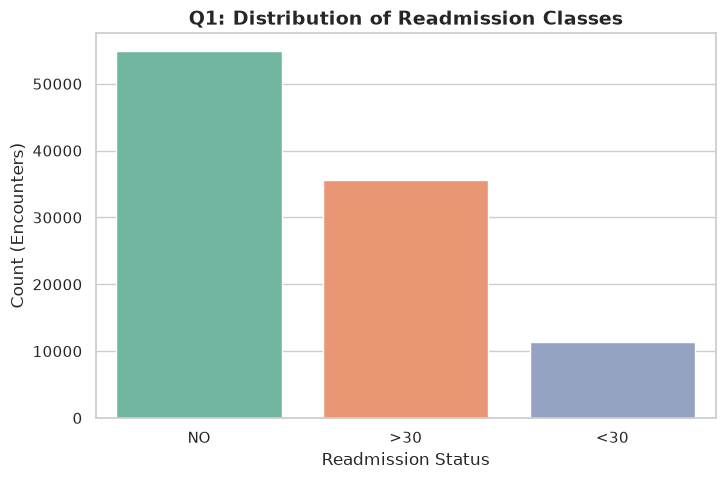

In [4]:
print("\n--- Q1: Target Distribution ---")
print(df['readmitted'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='readmitted', order=['NO', '>30', '<30'], palette='Set2')
plt.title('Q1: Distribution of Readmission Classes', fontsize=14, fontweight='bold')
plt.xlabel('Readmission Status', fontsize=12)
plt.ylabel('Count (Encounters)', fontsize=12)
plt.show()

### Missing values and data quality checks

/tmp/ipykernel_58207/1541279432.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='Reds_r')


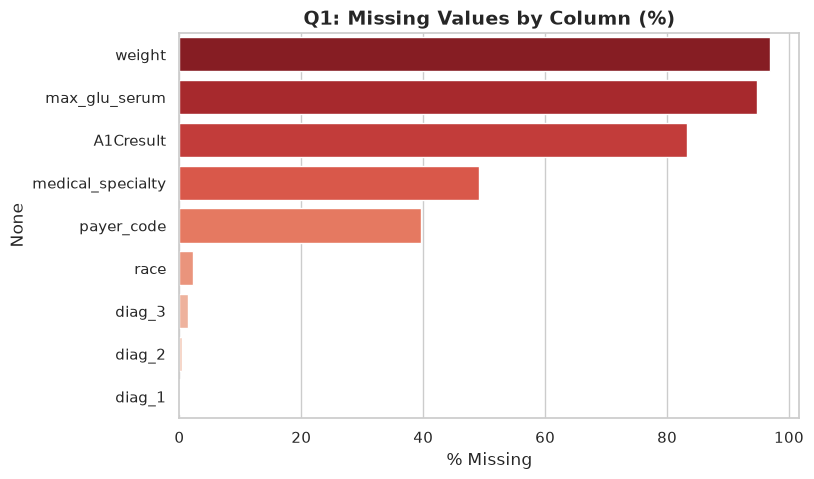


--- Repeat Patient Encounters ---
Patients with more than 1 encounter: 16773 out of 71518

--- Admission Type Counts ---
admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64


In [5]:
missing_pct = df.isna().mean().mul(100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(8, 5))
sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='Reds_r')
plt.title('Q1: Missing Values by Column (%)', fontsize=14, fontweight='bold')
plt.xlabel('% Missing', fontsize=12)
plt.show()

print("\n--- Repeat Patient Encounters ---")
enc_per_patient = df.groupby('patient_nbr').size()
print(f"Patients with more than 1 encounter: {(enc_per_patient > 1).sum()} out of {df['patient_nbr'].nunique()}")

print("\n--- Admission Type Counts ---")
print(df['admission_type_id'].value_counts())

### Demographic breakdown of patients

/tmp/ipykernel_58207/1091067022.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='age', order=sorted(df['age'].dropna().unique()), ax=axes[0], palette='Blues')
/tmp/ipykernel_58207/1091067022.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='race', order=df['race'].value_counts().index, ax=axes[1], palette='Blues')
/tmp/ipykernel_58207/1091067022.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='gender', ax=axes[2], palette='Blues')


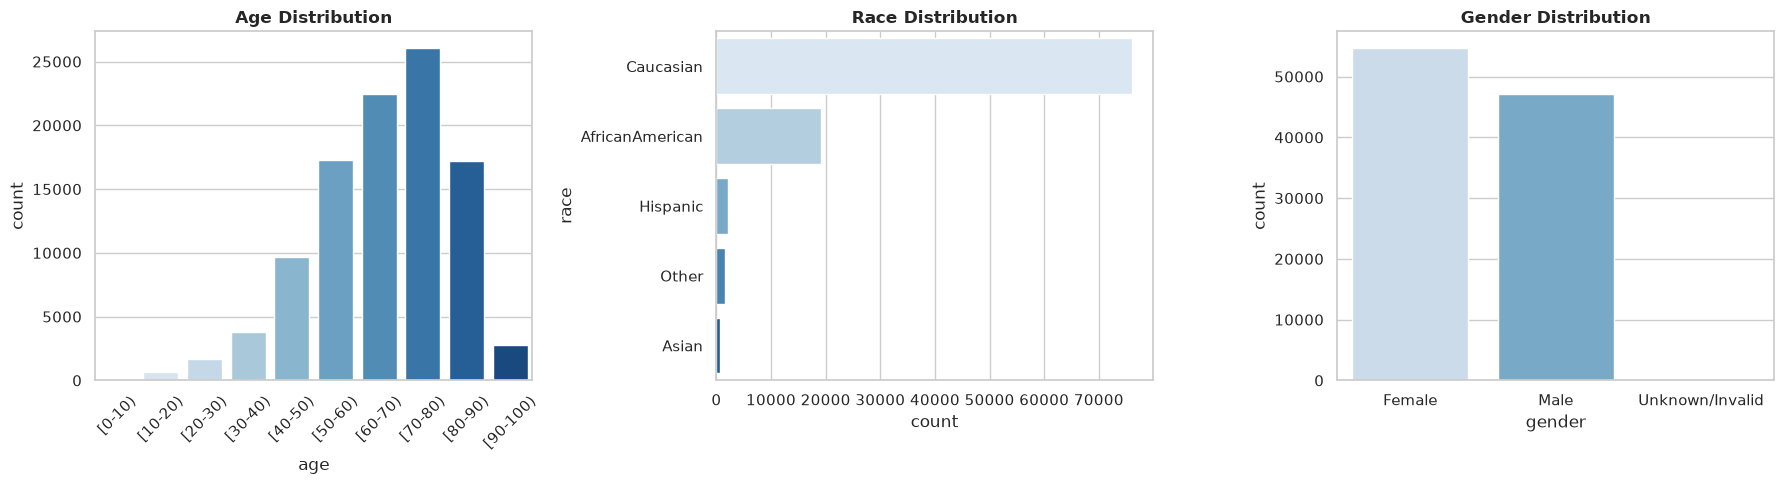

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='age', order=sorted(df['age'].dropna().unique()), ax=axes[0], palette='Blues')
axes[0].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, y='race', order=df['race'].value_counts().index, ax=axes[1], palette='Blues')
axes[1].set_title('Race Distribution', fontsize=12, fontweight='bold')

sns.countplot(data=df, x='gender', ax=axes[2], palette='Blues')
axes[2].set_title('Gender Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Q2: Measurements across Readmission Groups


--- Q2: Summary Statistics Across Readmission Groups ---

Metric: time_in_hospital
              count      mean       std  min  25%  50%  75%   max
readmitted                                                       
<30         11357.0  4.768249  3.028165  1.0  2.0  4.0  6.0  14.0
>30         35545.0  4.495541  2.988064  1.0  2.0  4.0  6.0  14.0
NO          54864.0  4.254429  2.964964  1.0  2.0  3.0  6.0  14.0

Metric: num_lab_procedures
              count       mean        std  min   25%   50%   75%    max
readmitted                                                             
<30         11357.0  44.226028  19.276087  1.0  33.0  45.0  58.0  132.0
>30         35545.0  43.836601  19.567515  1.0  32.0  45.0  58.0  129.0
NO          54864.0  42.381598  19.796262  1.0  30.0  44.0  56.0  126.0

Metric: num_medications
              count       mean       std  min   25%   50%   75%   max
readmitted                                                           
<30         11357.0  16.903143  8

/tmp/ipykernel_58207/2750655258.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='readmitted', y=metric, order=['NO', '>30', '<30'], ax=axes[i], palette='Pastel1', showfliers=False)
/tmp/ipykernel_58207/2750655258.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='readmitted', y=metric, order=['NO', '>30', '<30'], ax=axes[i], palette='Pastel1', showfliers=False)
/tmp/ipykernel_58207/2750655258.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='readmitted', y=metric, order=['NO', '>30', '<30'], ax=ax

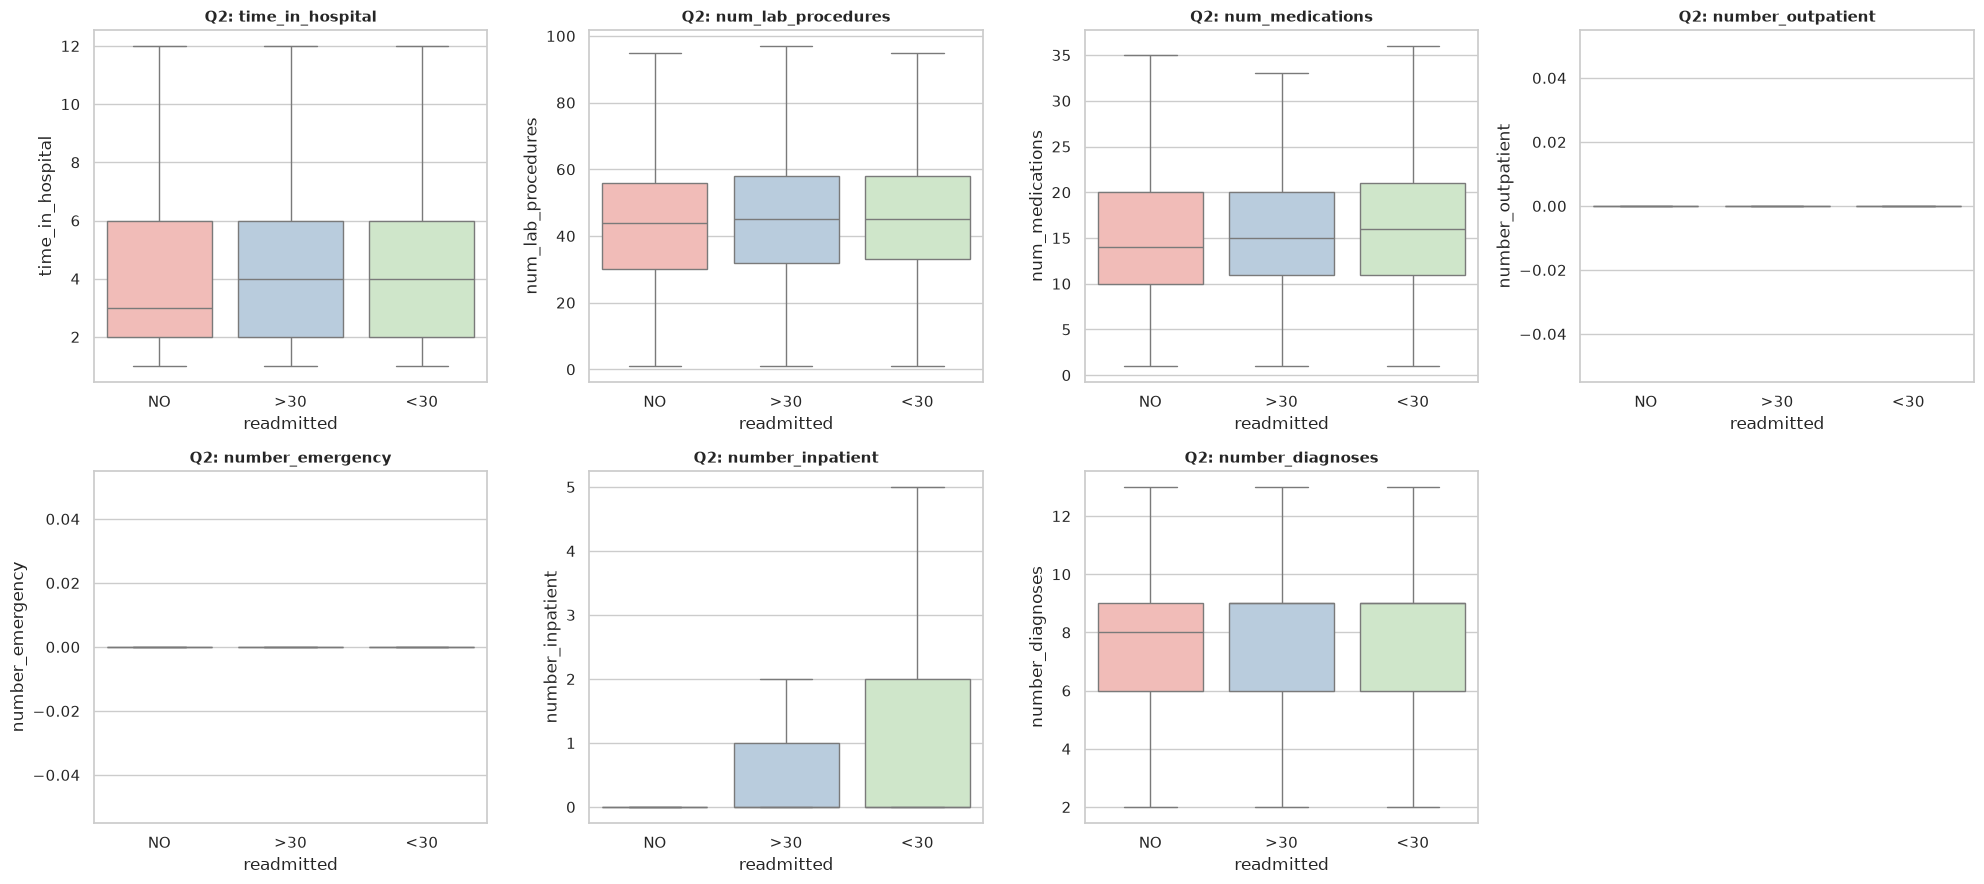

In [7]:
metrics = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

print("\n--- Q2: Summary Statistics Across Readmission Groups ---")
for metric in metrics:
    print(f"\nMetric: {metric}")
    print(df.groupby('readmitted')[metric].describe())

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.ravel()
for i, metric in enumerate(metrics):
    sns.boxplot(data=df, x='readmitted', y=metric, order=['NO', '>30', '<30'], ax=axes[i], palette='Pastel1', showfliers=False)
    axes[i].set_title(f'Q2: {metric}', fontsize=11, fontweight='bold')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

## Q3: Variables Associated with 30-Day Readmission


--- Q3: Binary Early Readmission Distribution ---
target_early_readmit
0    88.840084
1    11.159916
Name: proportion, dtype: float64


/tmp/ipykernel_58207/2426053135.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='target_early_readmit', y='number_inpatient', palette='viridis', ci=None)
/tmp/ipykernel_58207/2426053135.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='target_early_readmit', y='number_inpatient', palette='viridis', ci=None)


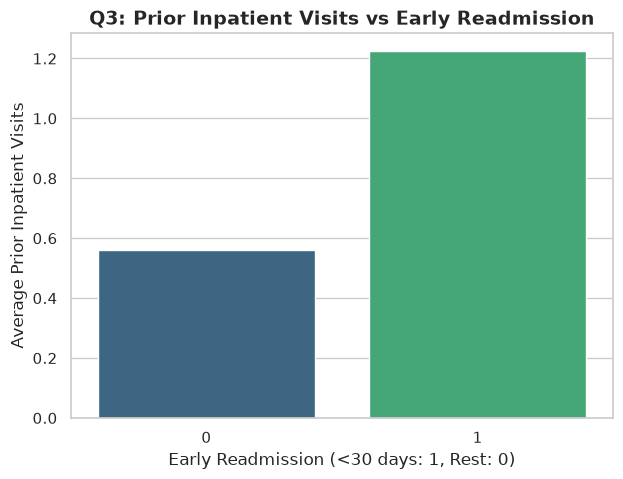

In [8]:
df['target_early_readmit'] = (df['readmitted'] == '<30').astype(int)

print("\n--- Q3: Binary Early Readmission Distribution ---")
print(df['target_early_readmit'].value_counts(normalize=True) * 100)

plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='target_early_readmit', y='number_inpatient', palette='viridis', ci=None)
plt.title('Q3: Prior Inpatient Visits vs Early Readmission', fontsize=14, fontweight='bold')
plt.xlabel('Early Readmission (<30 days: 1, Rest: 0)', fontsize=12)
plt.ylabel('Average Prior Inpatient Visits', fontsize=12)
plt.show()

### Early readmission rate by age and race

/tmp/ipykernel_58207/1561382263.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='age', y='target_early_readmit', order=sorted(df['age'].dropna().unique()), ax=axes[0], palette='viridis', ci=None)
/tmp/ipykernel_58207/1561382263.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='age', y='target_early_readmit', order=sorted(df['age'].dropna().unique()), ax=axes[0], palette='viridis', ci=None)
/tmp/ipykernel_58207/1561382263.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, y='race', x='target_early_readmit', order=df['race'].value_counts().index, ax=axes[1], palette='viridis', ci=None)
/tmp/ipykernel_58207/1561382263.py:8: FutureWarning: 

Passing `palette` without assigning `hue` 

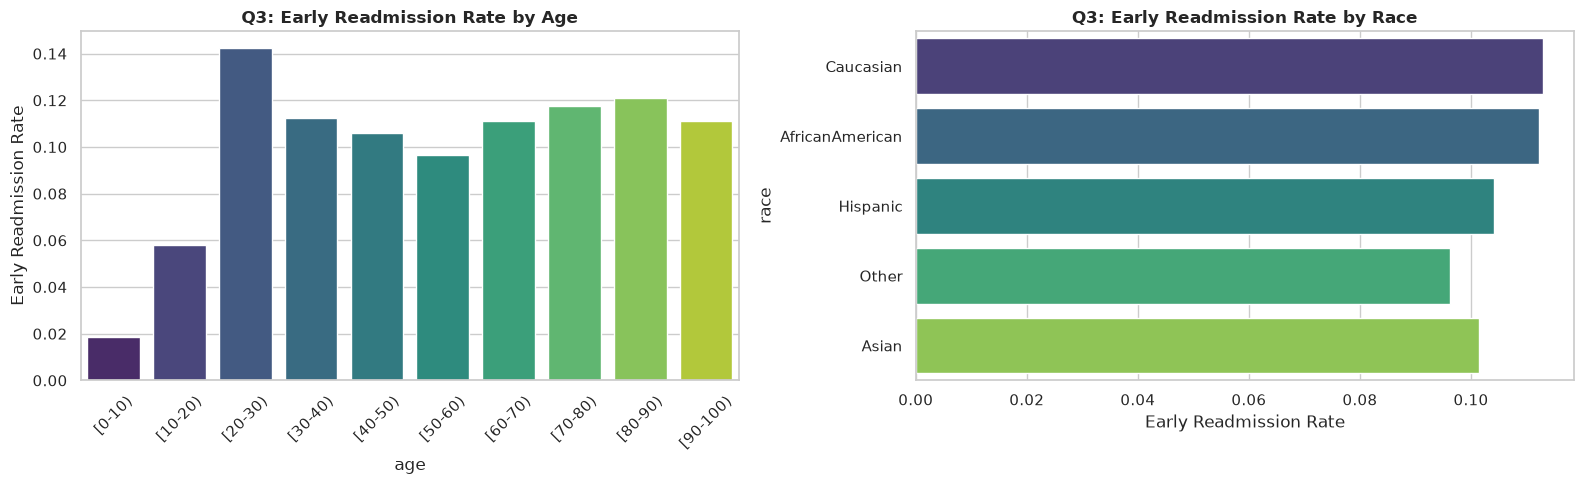

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=df, x='age', y='target_early_readmit', order=sorted(df['age'].dropna().unique()), ax=axes[0], palette='viridis', ci=None)
axes[0].set_title('Q3: Early Readmission Rate by Age', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Early Readmission Rate')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=df, y='race', x='target_early_readmit', order=df['race'].value_counts().index, ax=axes[1], palette='viridis', ci=None)
axes[1].set_title('Q3: Early Readmission Rate by Race', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Early Readmission Rate')

plt.tight_layout()
plt.show()

### Correlation of numeric variables with early readmission

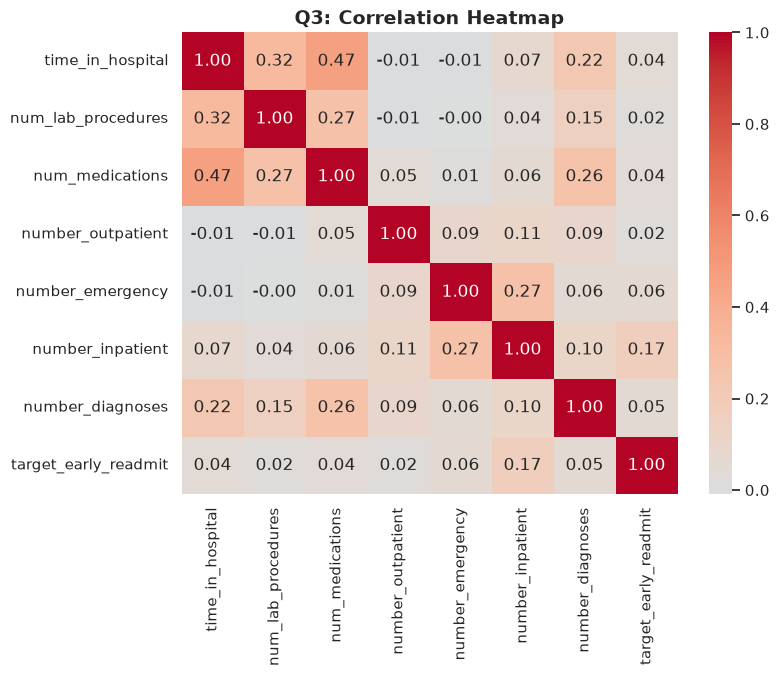

In [10]:
corr_cols = metrics + ['target_early_readmit']
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Q3: Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

## Q4: Minimal Preprocessing & Baseline Pipeline

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

numeric_features = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
categorical_features = ['race', 'gender', 'age']

model_cols = numeric_features + categorical_features + ['patient_nbr', 'target_early_readmit']
df_model = df[model_cols].dropna(subset=['target_early_readmit'])

patients = df_model['patient_nbr'].unique()
train_patients, test_patients = train_test_split(patients, test_size=0.2, random_state=42)

train_df = df_model[df_model['patient_nbr'].isin(train_patients)]
test_df = df_model[df_model['patient_nbr'].isin(test_patients)]

X_train = train_df[numeric_features + categorical_features]
y_train = train_df['target_early_readmit']
X_test = test_df[numeric_features + categorical_features]
y_test = test_df['target_early_readmit']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

baseline_pipeline.fit(X_train, y_train)
y_pred = baseline_pipeline.predict(X_test)

print("\n--- Q4: Baseline Pipeline Classification Report ---")
print(classification_report(y_test, y_pred))


--- Q4: Baseline Pipeline Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.71      0.80     18120
           1       0.17      0.49      0.25      2169

    accuracy                           0.68     20289
   macro avg       0.54      0.60      0.52     20289
weighted avg       0.84      0.68      0.74     20289



### Confusion matrix

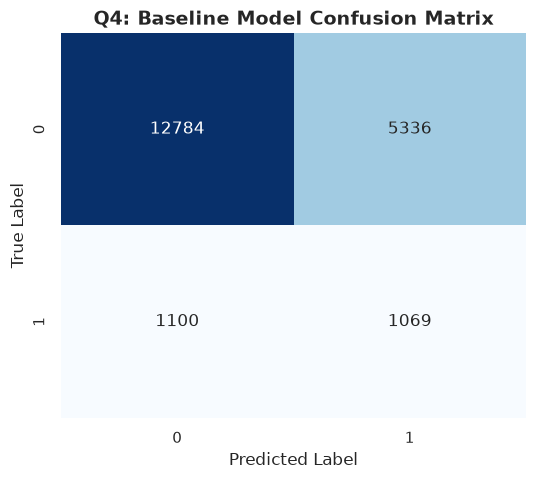

In [12]:
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Q4: Baseline Model Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

### Coefficient plot

/tmp/ipykernel_58207/4065303511.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='coefficient', y='feature', palette='coolwarm')


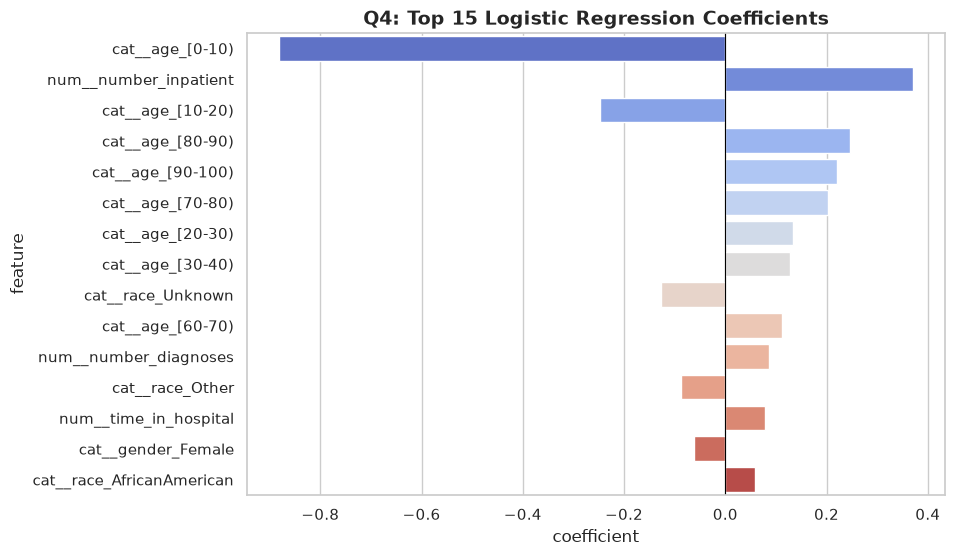

In [13]:
feature_names = baseline_pipeline.named_steps['preprocessor'].get_feature_names_out()
coefs = baseline_pipeline.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=coef_df, x='coefficient', y='feature', palette='coolwarm')
plt.title('Q4: Top 15 Logistic Regression Coefficients', fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()